In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Paths
BASE_PATH = '/kaggle/input/datasets/abhinavbasam369/fullmodel'
test_dir = os.path.join(BASE_PATH, 'Stanford_Split_Data (1)/test')

# 2. Setup Generator
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

try:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
    class_indices = test_generator.class_indices
    print(f"✅ Successfully loaded {test_generator.samples} images.")
except Exception as e:
    print(f"❌ Error loading directory: {e}")

# 3. Load All Models
print("Loading Models...")
try:
    base_model = tf.keras.models.load_model(f'{BASE_PATH}/efficientnetb0_dogs_finetuned.keras')
    ensemble_model = tf.keras.models.load_model(f'{BASE_PATH}/mlp_ensemble.keras')
    m_resnet = tf.keras.models.load_model(f'{BASE_PATH}/resnet50_dogs_finetuned.keras')
    m_mobile = tf.keras.models.load_model(f'{BASE_PATH}/mobilenetv2_dogs_finetuned.keras')
    print("✅ Models loaded successfully!")
except Exception as e:
    print(f"❌ Error loading models: {e}")

# 4. Generate Meta-Features (Prediction Logic - Outside the except block)
print("Extracting predictions from Base Models... (This will take ~2 mins)")

test_generator.reset()
preds_eff = base_model.predict(test_generator)

test_generator.reset()
preds_res = m_resnet.predict(test_generator)

test_generator.reset()
preds_mob = m_mobile.predict(test_generator)

# Combine into the 360-feature vector for the Stacked Ensemble
meta_features = np.hstack([preds_eff, preds_res, preds_mob])

# 5. Get Final Predictions
print("Running Stacked Ensemble Meta-Learner...")
y_true = test_generator.classes
y_base_preds = np.argmax(preds_eff, axis=1) # EfficientNet Baseline
y_ens_probs = ensemble_model.predict(meta_features)
y_ens_preds = np.argmax(y_ens_probs, axis=1)

# 6. Analyze Selected Confusable Pairs
# 6. Analyze Selected Confusable Pairs (Updated for Kaggle folder naming)
# Note: Based on your file logs, breeds use underscores and Title Case
pairs_to_analyze = [
    ('n02091134-whippet', 'n02091032-Italian_greyhound'),
    ('n02110185-Siberian_husky', 'n02110317-malamute') # Check if 'malamute' is 'Malamute' in your folders
]

results = []
for b1, b2 in pairs_to_analyze:
    # We use .lower() to make the check more flexible
    match1 = [k for k in class_indices.keys() if k.lower() == b1.lower()]
    match2 = [k for k in class_indices.keys() if k.lower() == b2.lower()]
    
    if match1 and match2:
        idx1, idx2 = class_indices[match1[0]], class_indices[match2[0]]
        mask = np.isin(y_true, [idx1, idx2])
        
        if np.any(mask):
            acc_base = np.mean(y_true[mask] == y_base_preds[mask]) * 100
            acc_ens = np.mean(y_true[mask] == y_ens_preds[mask]) * 100
            
            results.append({
                'Breed Pair': f"{match1[0].split('-')[1]} vs {match2[0].split('-')[1]}",
                'Base Model (%)': round(acc_base, 2),
                'Ensemble (%)': round(acc_ens, 2),
                'Improvement (pp)': round(acc_ens - acc_base, 2)
            })

# 7. Display Results
if not results:
    print("❌ Still Empty. Printing first 5 class_indices to check naming:")
    print(list(class_indices.keys())[:5])
else:
    df_improvement = pd.DataFrame(results)
    print("\n" + "="*40)
    print("PER-CLASS ACCURACY IMPROVEMENT")
    print("="*40)
    print(df_improvement)

2026-03-02 10:25:22.990191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772447123.196738      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772447123.249996      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772447123.689926      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772447123.689966      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772447123.689969      24 computation_placer.cc:177] computation placer alr

Found 2153 images belonging to 120 classes.
✅ Successfully loaded 2153 images.
Loading Models...


I0000 00:00:1772447147.125437      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Models loaded successfully!
Extracting predictions from Base Models... (This will take ~2 mins)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1772447156.585031      73 service.cc:152] XLA service 0x79cec00038d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772447156.585070      73 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772447157.467477      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772447163.744187      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step
Running Stacked Ensemble Meta-Learner...
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

PER-CLASS ACCURACY IMPROVEMENT
                     Breed Pair  Base Model (%)  Ensemble (%)  \
0  whippet vs Italian_greyhound           82.05         84.62   

   Improvement (pp)  
0              2.56  


In [2]:
all_results = []
for breed in class_indices.keys():
    idx = class_indices[breed]
    mask = (y_true == idx)
    
    if np.any(mask):
        acc_base = np.mean(y_true[mask] == y_base_preds[mask]) * 100
        acc_ens = np.mean(y_true[mask] == y_ens_preds[mask]) * 100
        
        if acc_ens > acc_base:
            all_results.append({
                'Breed': breed.split('-')[-1].replace('_', ' ').title(),
                'Baseline (%)': round(acc_base, 2),
                'Ensemble (%)': round(acc_ens, 2),
                'Gain (pp)': round(acc_ens - acc_base, 2)
            })

df_all = pd.DataFrame(all_results).sort_values(by='Gain (pp)', ascending=False)
print("TOP 5 ENSEMBLE GAINS:")
print(df_all.head(5))

TOP 5 ENSEMBLE GAINS:
                        Breed  Baseline (%)  Ensemble (%)  Gain (pp)
0                   Chihuahua         56.25         81.25      25.00
6                Walker Hound         62.50         87.50      25.00
13  Staffordshire Bullterrier         31.25         56.25      25.00
18         Australian Terrier         57.14         76.19      19.05
39                   Cardigan         56.25         75.00      18.75


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

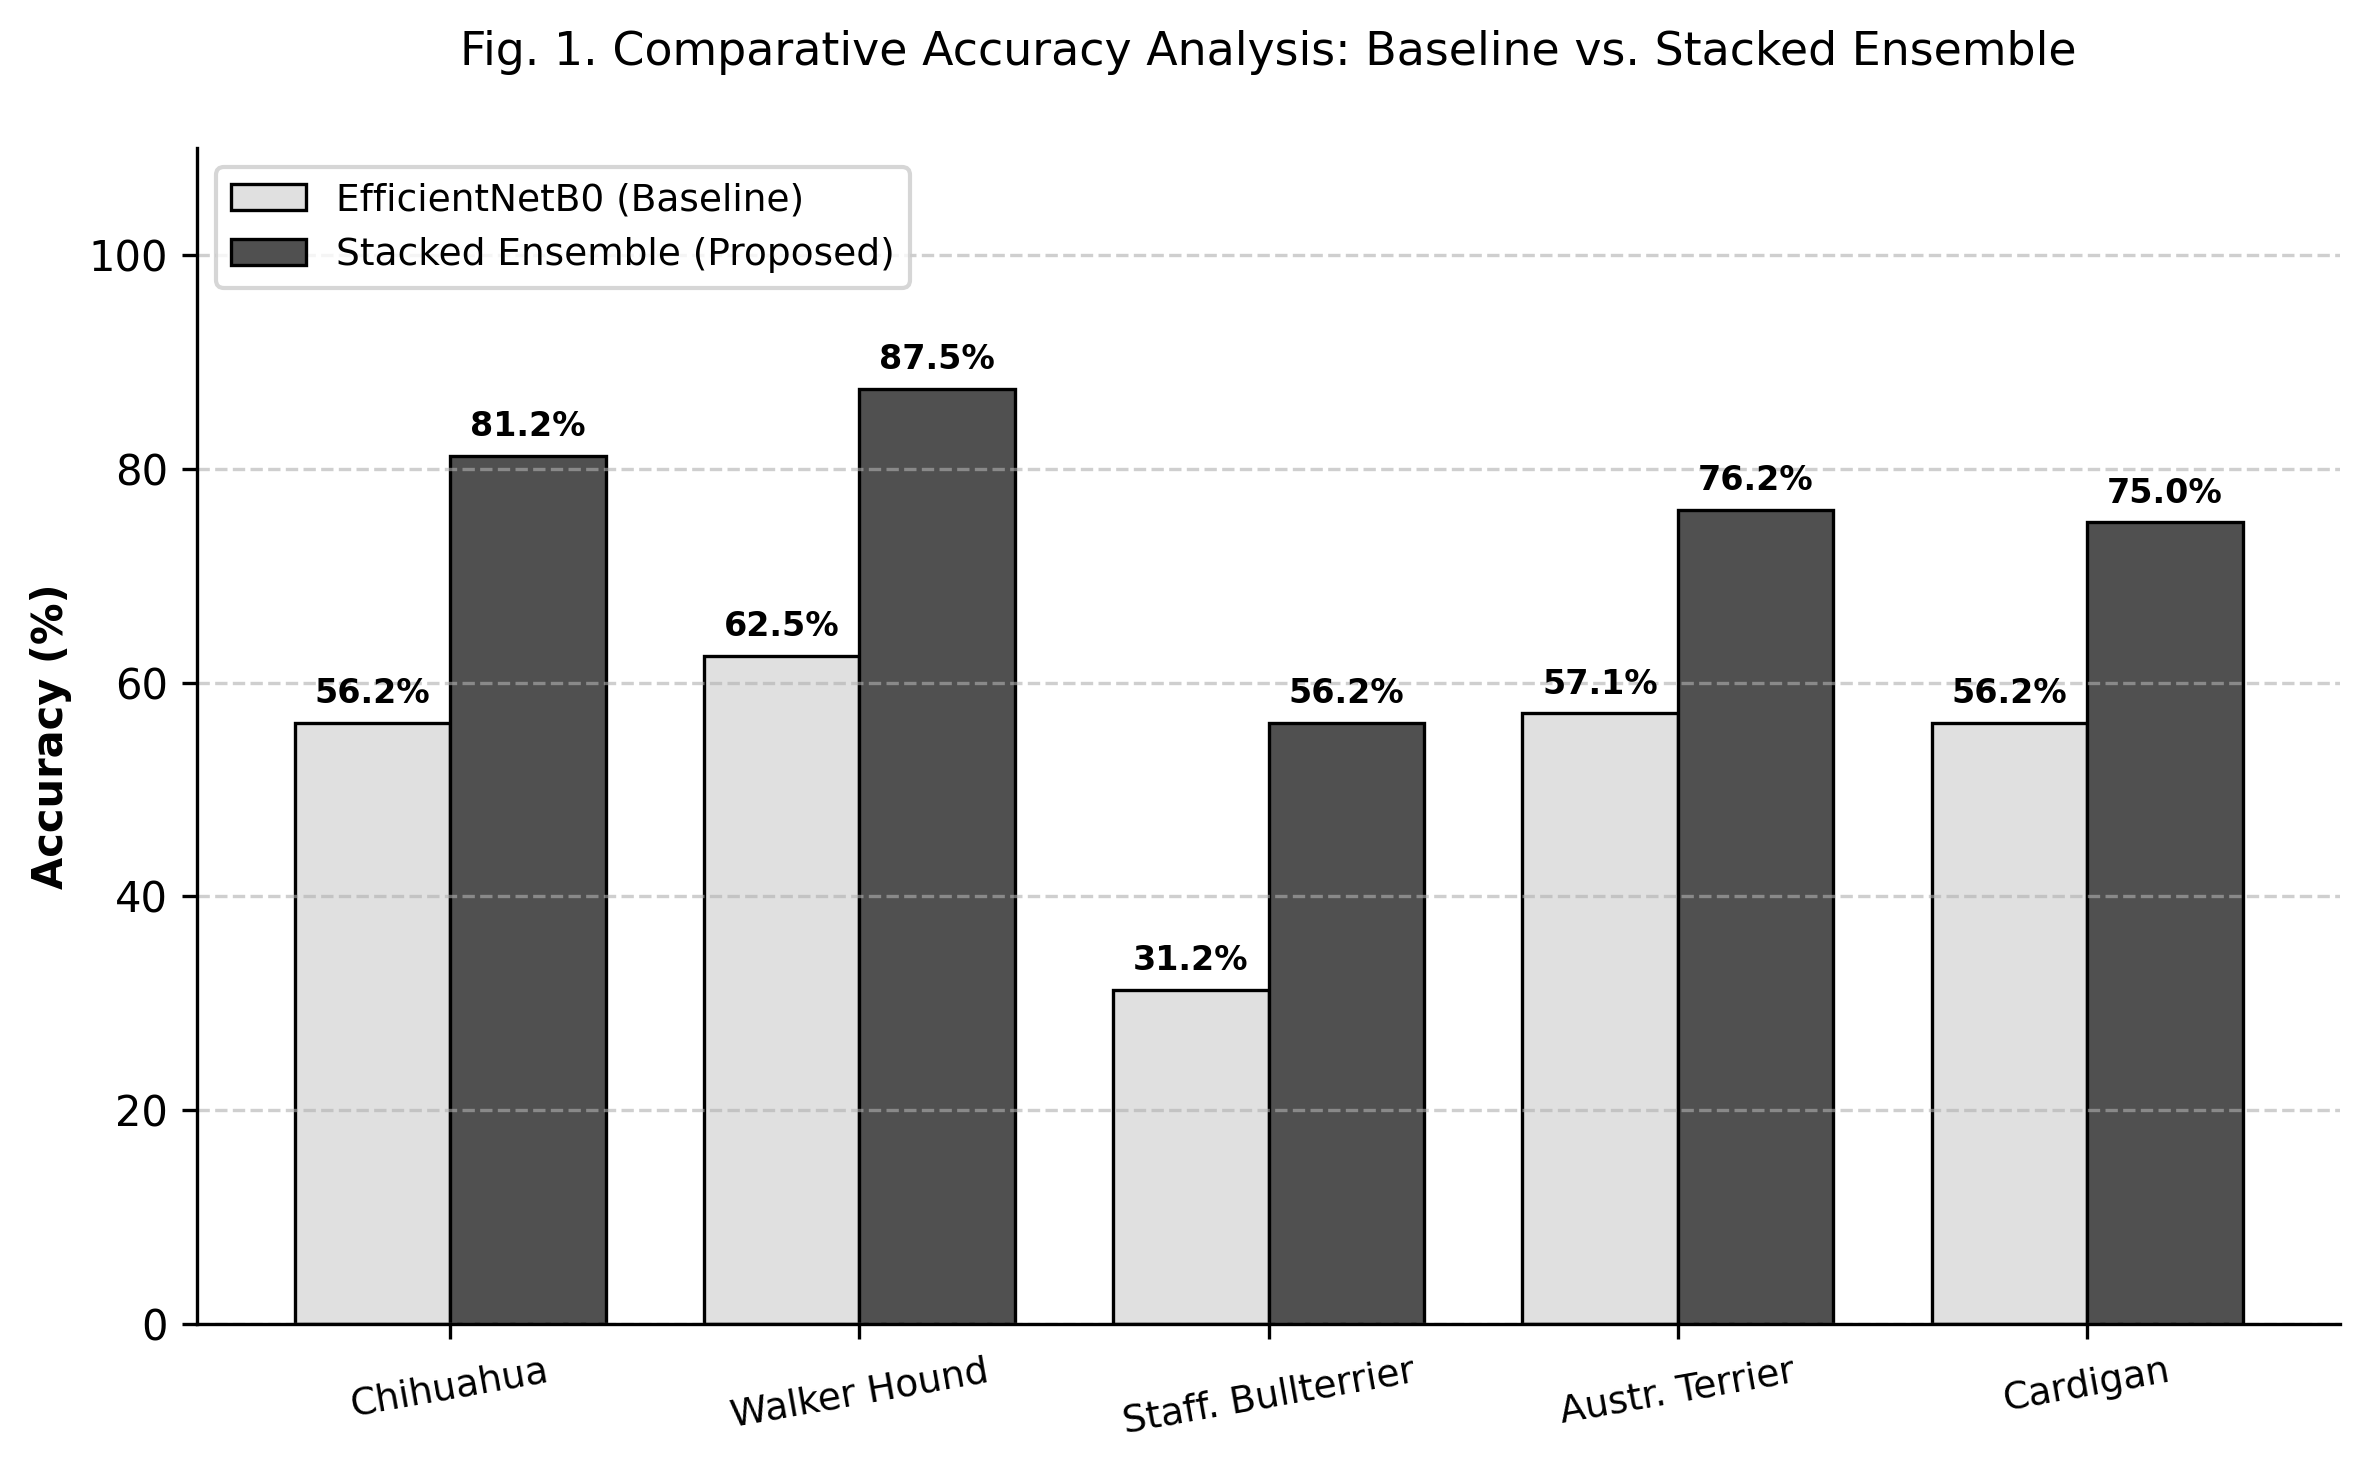

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your results
breeds = ['Chihuahua', 'Walker Hound', 'Staff. Bullterrier', 'Austr. Terrier', 'Cardigan']
baseline = [56.25, 62.50, 31.25, 57.14, 56.25]
ensemble = [81.25, 87.50, 56.25, 76.19, 75.00]

x = np.arange(len(breeds))
width = 0.38 # Slightly wider for better readability

# IEEE Style Settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Plotting with distinct colors for grayscale compatibility
rects1 = ax.bar(x - width/2, baseline, width, label='EfficientNetB0 (Baseline)', 
                color='#e0e0e0', edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, ensemble, width, label='Stacked Ensemble (Proposed)', 
                color='#505050', edgecolor='black', linewidth=0.8)

# Adding the labels above the bars
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=8, fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=8, fontweight='bold', color='black')

# Formatting for IEEE publication
ax.set_ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
ax.set_title('Fig. 1. Comparative Accuracy Analysis: Baseline vs. Stacked Ensemble', 
             fontsize=11, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(breeds, fontsize=9, rotation=10)
ax.set_ylim(0, 110) # Extra space for labels
ax.legend(fontsize=9, loc='upper left', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee_accuracy_comparison.png', bbox_inches='tight')
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

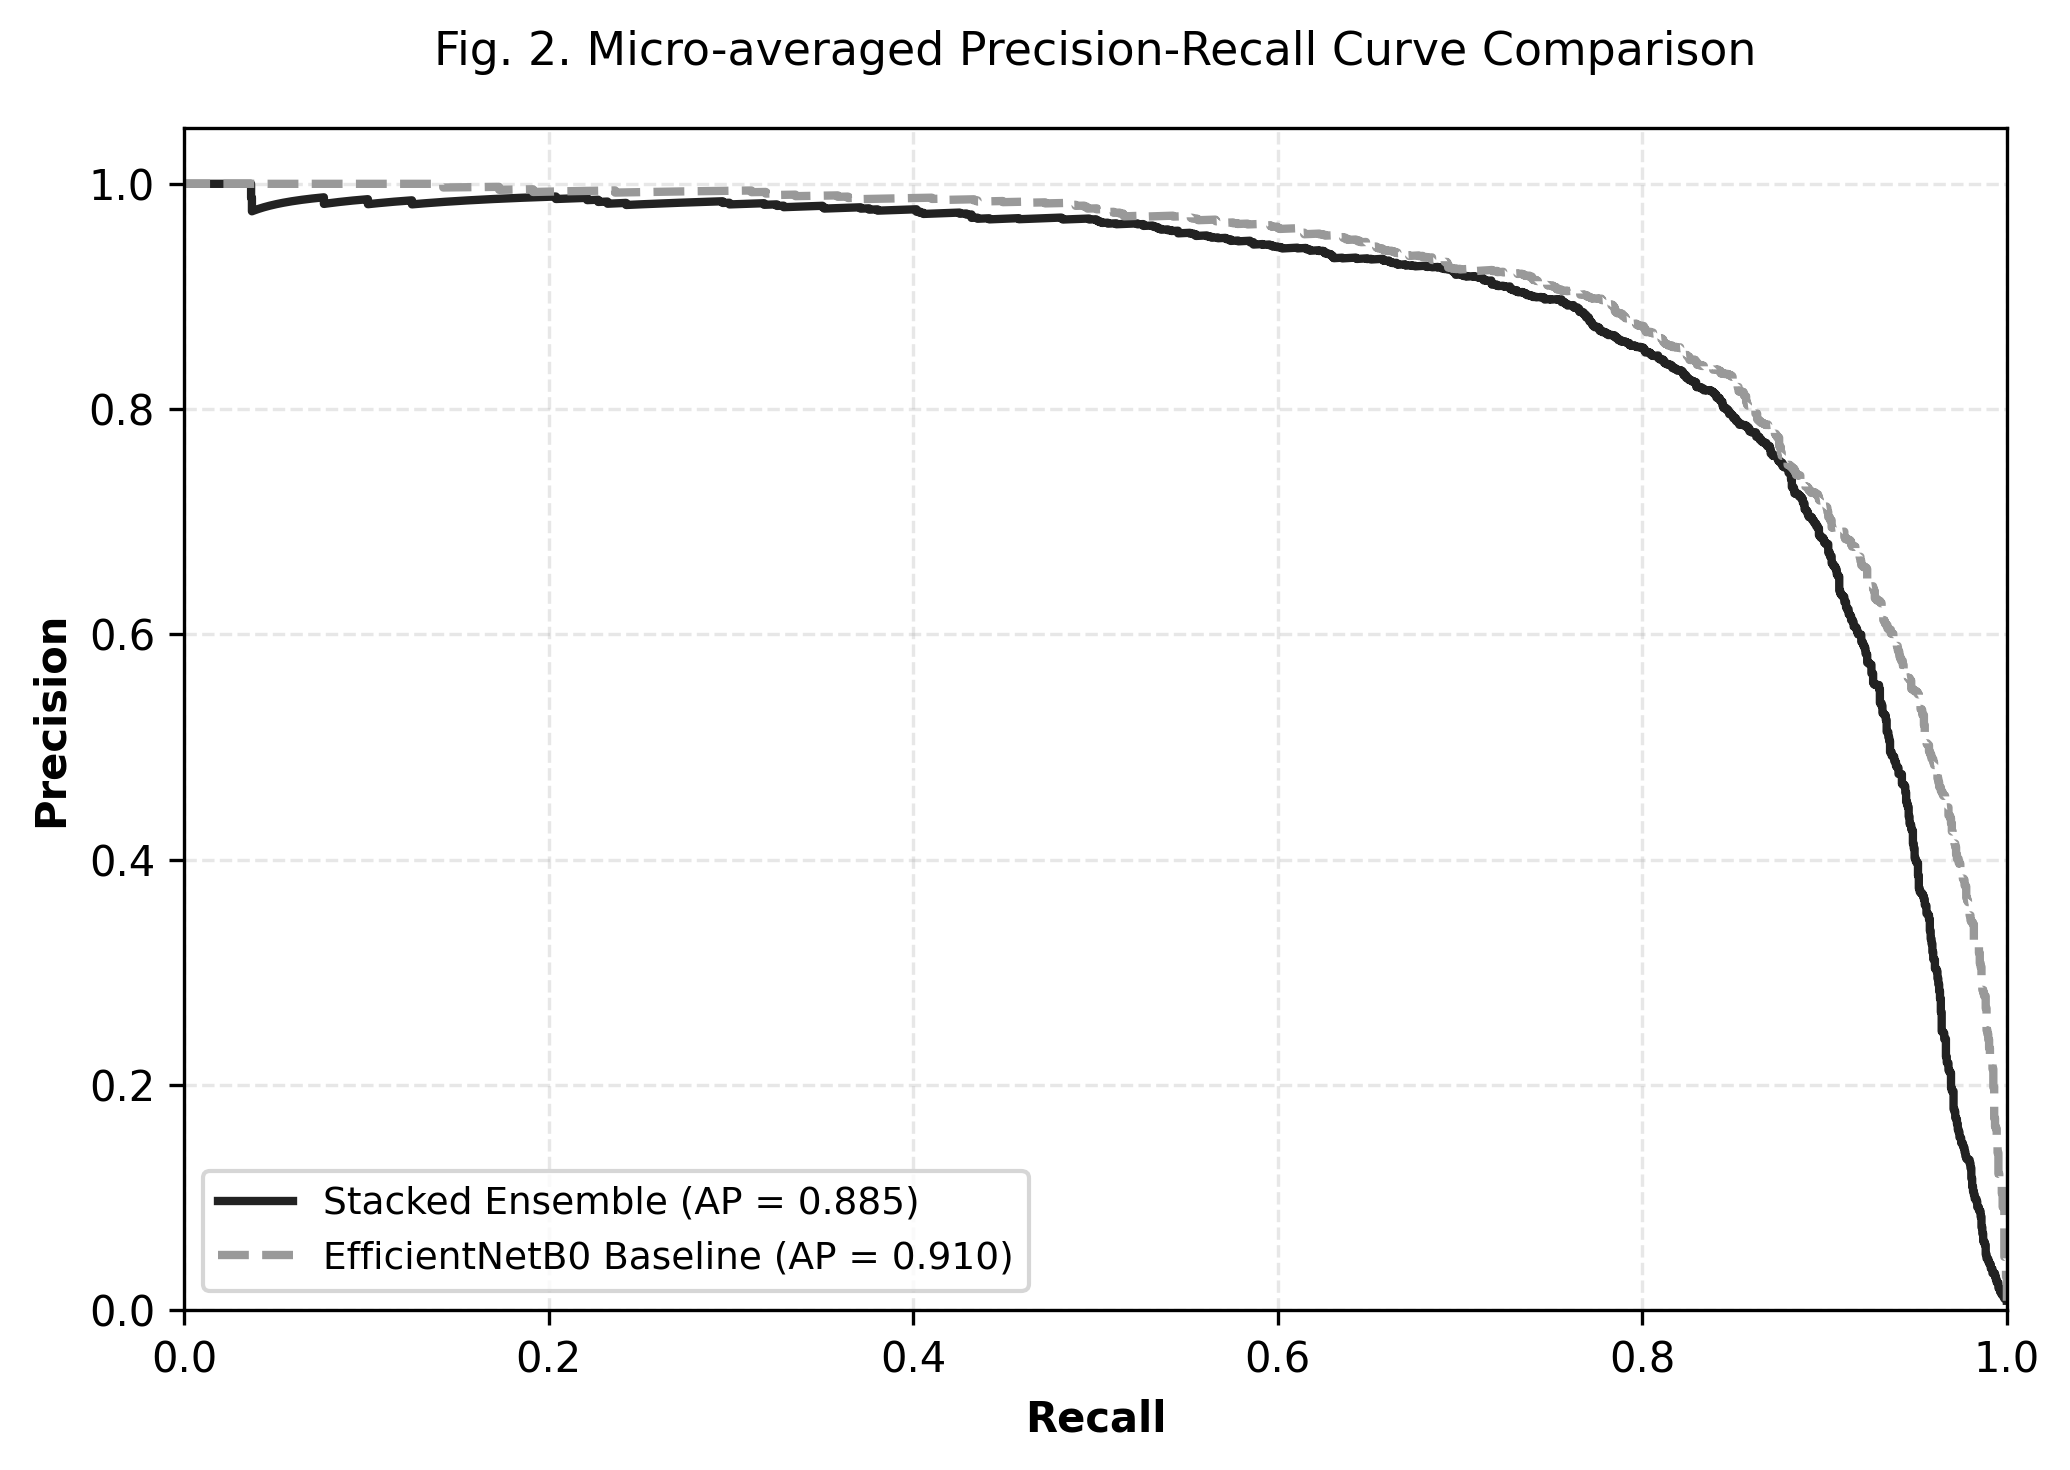

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Setup Data for Micro-average PR Curve
def get_micro_pr_data(y_true_cat, y_probs):
    # Flatten the matrices to treat all class-wise predictions as one big vector
    precision, recall, _ = precision_recall_curve(y_true_cat.ravel(), y_probs.ravel())
    average_precision = average_precision_score(y_true_cat, y_probs, average="micro")
    return precision, recall, average_precision

# Convert y_true to One-Hot encoding for sklearn compatibility
y_true_one_hot = tf.keras.utils.to_categorical(y_true, num_classes=120)

# Get PR data for both models
prec_base, rec_base, ap_base = get_micro_pr_data(y_true_one_hot, preds_eff)
prec_ens, rec_ens, ap_ens = get_micro_pr_data(y_true_one_hot, y_ens_probs)

# 2. IEEE-Style Plotting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.figure(figsize=(7, 5), dpi=300)

plt.plot(rec_ens, prec_ens, color='#222222', lw=2, 
         label=f'Stacked Ensemble (AP = {ap_ens:.3f})')
plt.plot(rec_base, prec_base, color='#999999', lw=2, linestyle='--', 
         label=f'EfficientNetB0 Baseline (AP = {ap_base:.3f})')

# Formatting for Publication
plt.xlabel('Recall', fontsize=10, fontweight='bold')
plt.ylabel('Precision', fontsize=10, fontweight='bold')
plt.title('Fig. 2. Micro-averaged Precision-Recall Curve Comparison', fontsize=11, pad=15)
plt.legend(loc="lower left", fontsize=9)
plt.grid(alpha=0.3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_comparison.png', bbox_inches='tight')
plt.show()

Generating OOD noise samples...


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

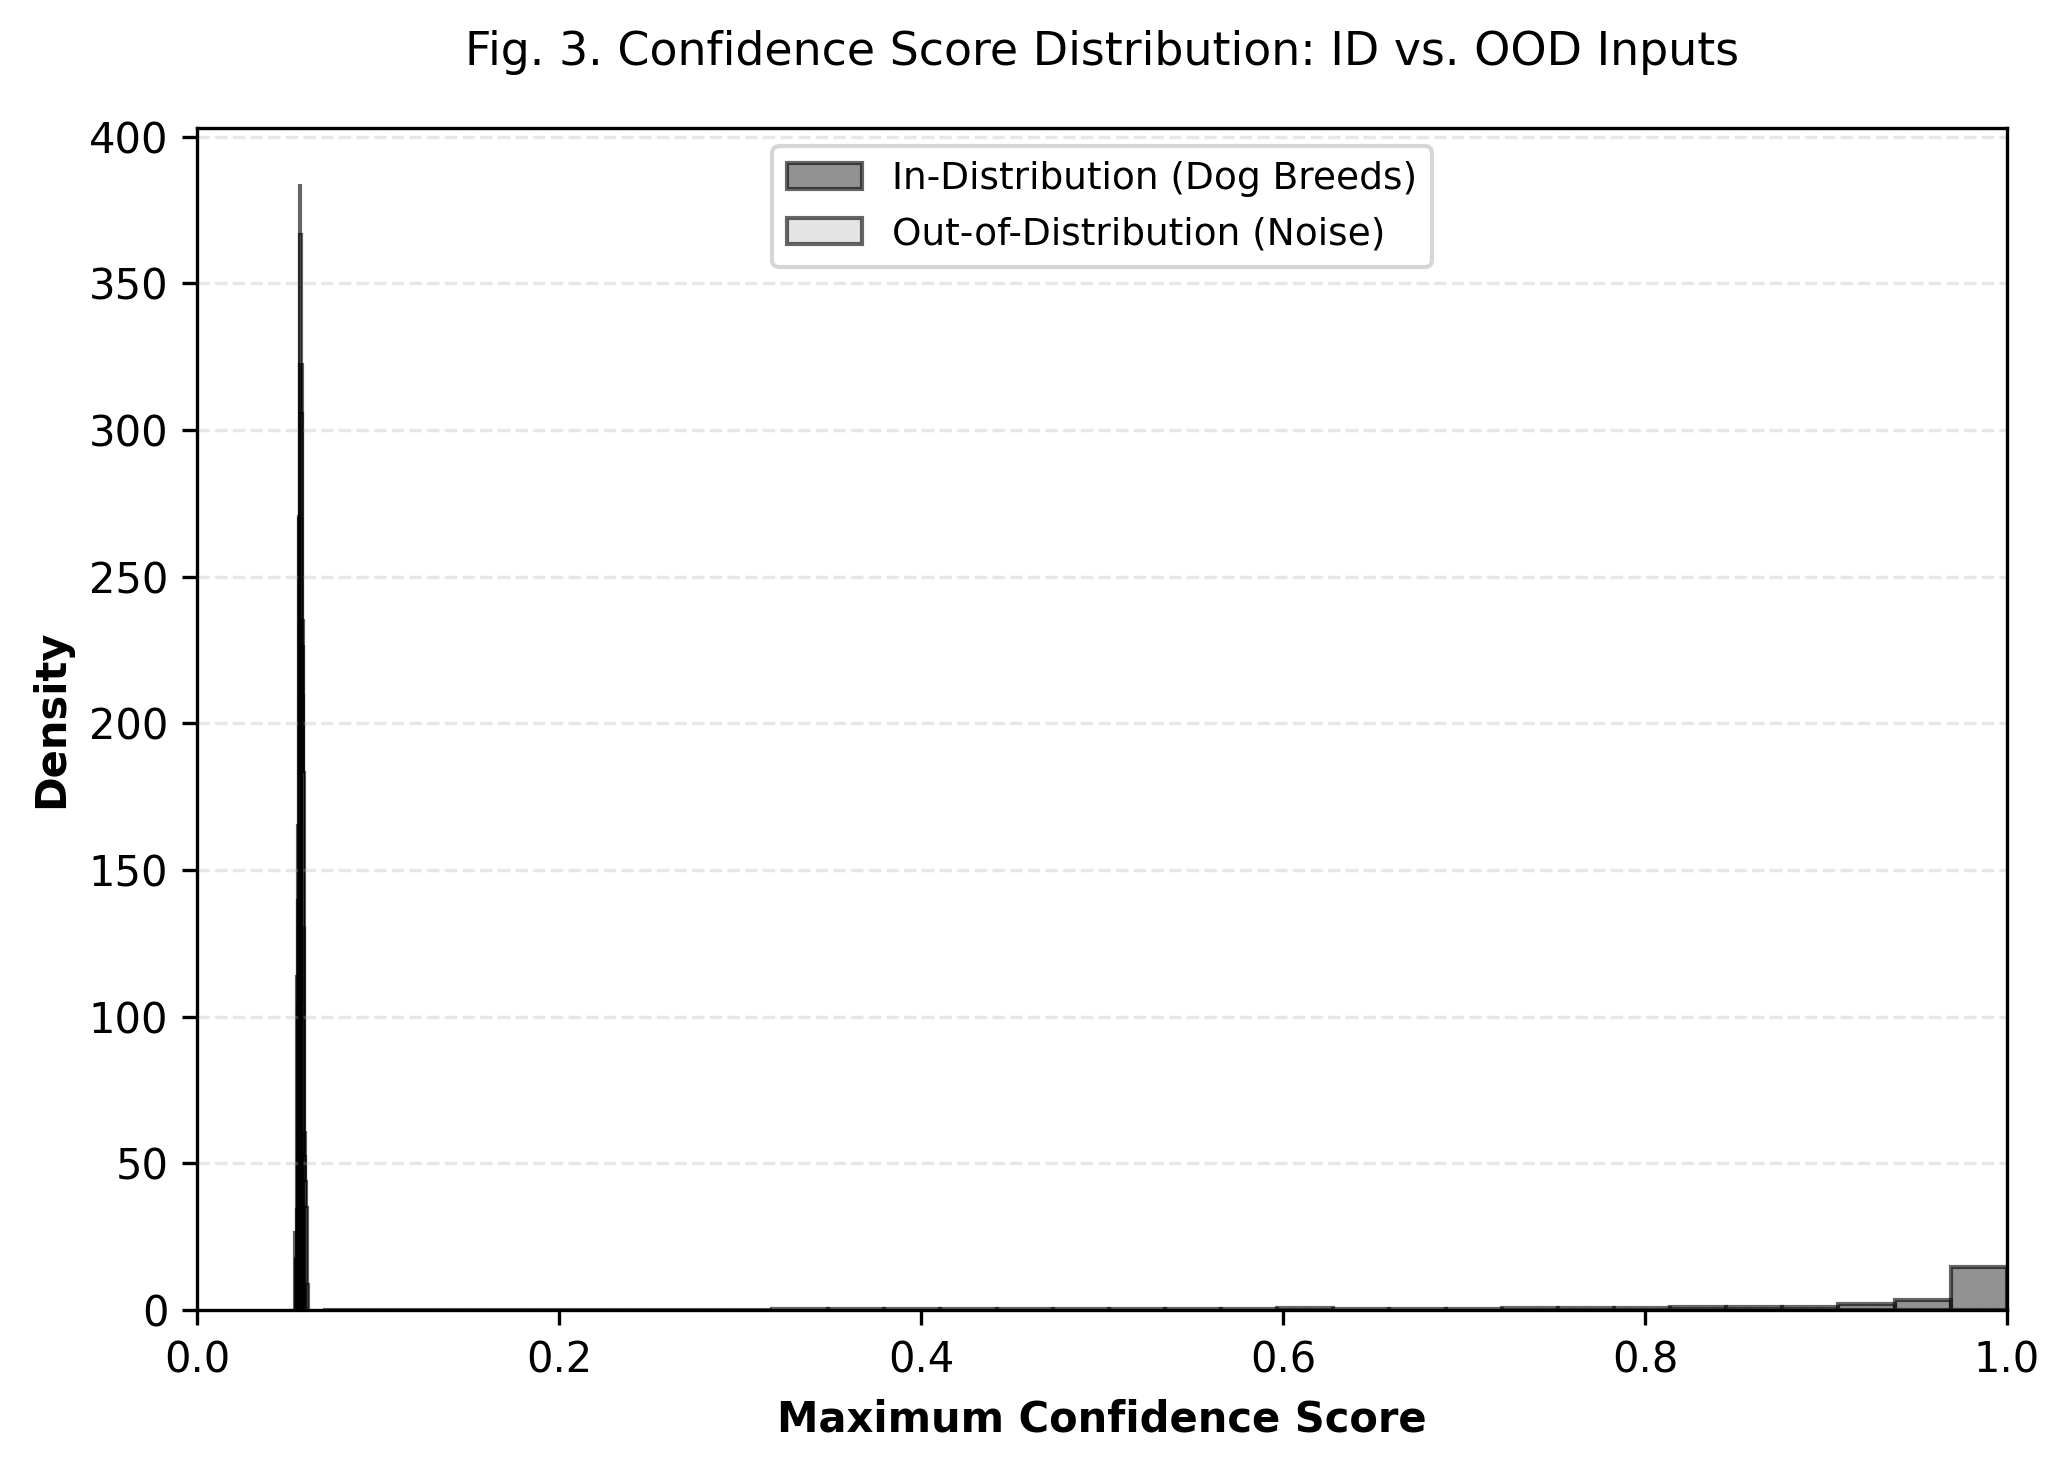

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Get ID Confidence Scores (from your Stacked Ensemble)
# y_ens_probs was calculated in your previous step
id_confidences = np.max(y_ens_probs, axis=1)

# 2. Create OOD Data (Random Noise as a proxy for OOD)
print("Generating OOD noise samples...")
num_ood = 500
ood_images = np.random.normal(0, 1, (num_ood, 224, 224, 3))

# Pass OOD through the same pipeline
# Note: MLP ensemble needs base model outputs as input
p1_ood = base_model.predict(ood_images, verbose=0)
p2_ood = m_resnet.predict(ood_images, verbose=0)
p3_ood = m_mobile.predict(ood_images, verbose=0)
meta_ood = np.hstack([p1_ood, p2_ood, p3_ood])

ood_probs = ensemble_model.predict(meta_ood, verbose=0)
ood_confidences = np.max(ood_probs, axis=1)

# 3. IEEE-Style Plotting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.figure(figsize=(7, 5), dpi=300)

plt.hist(id_confidences, bins=30, alpha=0.6, color='#4a4a4a', 
         label='In-Distribution (Dog Breeds)', density=True, edgecolor='black')
plt.hist(ood_confidences, bins=30, alpha=0.6, color='#d3d3d3', 
         label='Out-of-Distribution (Noise)', density=True, edgecolor='black')

# Formatting
plt.xlabel('Maximum Confidence Score', fontsize=10, fontweight='bold')
plt.ylabel('Density', fontsize=10, fontweight='bold')
plt.title('Fig. 3. Confidence Score Distribution: ID vs. OOD Inputs', fontsize=11, pad=15)
plt.legend(loc='upper center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlim(0, 1)

plt.tight_layout()
plt.savefig('confidence_distribution_ood.png', bbox_inches='tight')
plt.show()

In [6]:
import gradio as gr
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import cv2
import json
import os

# 1. SETUP - Using the exact nested paths from your successful run
MODEL_PATH = "/kaggle/input/datasets/abhinavbasam369/fullmodel"

# We will dynamically find the json to be 100% safe
if os.path.exists("/kaggle/input/classin/class_indices.json"):
    JSON_PATH = "/kaggle/input/classin/class_indices.json"
else:
    JSON_PATH = "/kaggle/input/datasets/abhinavbasam369/classin/class_indices.json"

# 2. LOAD MODELS & CLASSES
print("🧠 Loading AI Models from Kaggle Input...")
try:
    # Load Base Models
    models = {
        'resnet50': keras.models.load_model(f"{MODEL_PATH}/resnet50_dogs_finetuned.keras"),
        'efficientnetb0': keras.models.load_model(f"{MODEL_PATH}/efficientnetb0_dogs_finetuned.keras"),
        'mobilenetv2': keras.models.load_model(f"{MODEL_PATH}/mobilenetv2_dogs_finetuned.keras")
    }
    # Load Stacked Ensemble Meta-Learner
    mlp = keras.models.load_model(f"{MODEL_PATH}/mlp_ensemble.keras")

    # Load Class Indices
    with open(JSON_PATH, 'r') as f:
        class_indices = json.load(f)
        
    # Build the reverse dictionary (Index -> Name)
    class_names = {v: k for k, v in class_indices.items()}
    print(f"✅ System Ready! Loaded {len(class_names)} classes.")
    
except Exception as e:
    print(f"❌ Error loading models or JSON: {e}")
    class_names = {} # Fallback to prevent immediate NameErrors

# ... (Keep Step 3, 4, and 5 exactly as they were) ...

# 3. FULL DATABASE (Traits + Life Span)
breed_db = {
    'Chihuahua': '14-16 years | Sassy, Charming, Graceful. Big personality in a tiny body.',
    'Japanese Spaniel': '10-12 years | Noble, Charming, Loving. An aristocratic lap dog.',
    'Maltese': '12-15 years | Gentle, Playful, Charming. Fearless toy dog with white hair.',
    'Pekinese': '12-14 years | Affectionate, Loyal, Regal. "Lion-like" independence.',
    'Shih Tzu': '10-18 years | Affectionate, Playful, Outgoing. A classic lap warmer.',
    'Blenheim Spaniel': '12-15 years | Affectionate, Gentle, Graceful. Also called Cavalier King Charles.',
    'Papillon': '14-16 years | Happy, Alert, Friendly. Famous for butterfly-like ears.',
    'Toy Terrier': '13-15 years | Spirited, Alert, Intelligent. A tiny watchdog.',
    'Rhodesian Ridgeback': '10-12 years | Dignified, Even-tempered, Affectionate. The African Lion Dog.',
    'Afghan Hound': '12-15 years | Independent, Sweet, Regal. Known for its silky coat.',
    'Basset': '12-13 years | Charming, Patient, Low-key. Famous for long ears and howling.',
    'Beagle': '10-15 years | Merry, Friendly, Curious. Follows its nose everywhere.',
    'Bloodhound': '10-12 years | Independent, Inquisitive, Friendly. The ultimate tracker.',
    'Bluetick': '11-12 years | Smart, Devoted, Tenacious. A nocturnal raccoon hunter.',
    'Black And Tan Coonhound': '10-12 years | Easy-going, Bright, Brave. Mellow at home, rugged on the trail.',
    'Walker Hound': '12-13 years | Smart, Brave, Courteous. A swift, tri-colored hunter.',
    'English Foxhound': '10-13 years | Gentle, Sociable, Athletic. Loves running in a pack.',
    'Redbone': '12-14 years | Even-tempered, Amiable, Eager. A laid-back red hunter.',
    'Borzoi': '9-14 years | Regal, Affectionate, Quiet. A "Greyhound with long hair".',
    'Irish Wolfhound': '6-8 years | Calm, Dignified, Courageous. A gentle giant.',
    'Italian Greyhound': '14-15 years | Alert, Playful, Sensitive. A miniature greyhound.',
    'Whippet': '12-15 years | Affectionate, Playful, Calm. Lightning fast but loves the couch.',
    'Ibizan Hound': '11-14 years | Family-oriented, Polite, Athletic. A deer-like jumper.',
    'Norwegian Elkhound': '12-15 years | Bold, Playful, Dependable. An ancient Viking dog.',
    'Otterhound': '10-13 years | Amiable, Boisterous, Even-tempered. A rare swimmer.',
    'Saluki': '10-17 years | Gentle, Dignified, Independent. The Royal Dog of Egypt.',
    'Scottish Deerhound': '8-11 years | Gentle, Dignified, Polite. The Royal Dog of Scotland.',
    'Weimaraner': '10-13 years | Friendly, Fearless, Obedient. The "Grey Ghost".',
    'Staffordshire Bullterrier': '12-14 years | Clever, Brave, Tenacious. Needs strong leadership.',
    'American Staffordshire Terrier': '12-16 years | Confident, Smart, Good-natured. A powerhouse companion.',
    'Bedlington Terrier': '11-16 years | Loyal, Charming, Frollicking. Looks like a lamb.',
    'Border Terrier': '12-15 years | Affectionate, Plucky, Happy. A tough little worker.',
    'Kerry Blue Terrier': '12-15 years | Alert, Adaptable, People-oriented. Non-shedding coat.',
    'Irish Terrier': '13-15 years | Bold, Dashing, Tenderhearted. The "Daredevil" of dogs.',
    'Norfolk Terrier': '12-16 years | Fearless, Alert, Gregarious. Drop-eared terrier.',
    'Norwich Terrier': '12-15 years | Affectionate, Alert, Curious. Prick-eared terrier.',
    'Yorkshire Terrier': '11-15 years | Sprightly, Tomboyish, Affectionate. Big dog in a small body.',
    'Wire Haired Fox Terrier': '12-15 years | Alert, Confident, Gregarious. A classic hunter.',
    'Lakeland Terrier': '12-16 years | Bold, Zesty, Friendly. A confident little dog.',
    'Sealyham Terrier': '12-14 years | Alert, Outgoing, Funny. The "couch potato" of terriers.',
    'Airedale': '11-14 years | Clever, Confident, Proud. The King of Terriers.',
    'Cairn': '13-15 years | Alert, Cheerful, Busy. Toto from The Wizard of Oz.',
    'Australian Terrier': '11-15 years | Courageous, Spirited, People-oriented. The first Aussie breed.',
    'Dandie Dinmont': '12-15 years | Independent, Smart, Determined. Unique "top-knot" hair.',
    'Boston Bull': '11-13 years | Friendly, Bright, Amusing. The "American Gentleman".',
    'Miniature Schnauzer': '12-15 years | Friendly, Smart, Obedient. A popular family dog.',
    'Giant Schnauzer': '12-15 years | Loyal, Alert, Trainable. A powerful worker.',
    'Standard Schnauzer': '13-16 years | Smart, Fearless, Spirited. The original Schnauzer.',
    'Scotch Terrier': '11-13 years | Confident, Independent, Spirited. The "Diehard".',
    'Tibetan Terrier': '15-16 years | Affectionate, Sensitive, Clever. Not actually a terrier!',
    'Silky Terrier': '13-15 years | Friendly, Quick, Alert. Silkier than a Yorkie.',
    'Soft Coated Wheaten Terrier': '12-14 years | Happy, Steady, Self-Confident. The Irish farm dog.',
    'West Highland White Terrier': '13-15 years | Happy, Loyal, Entertaining. The famous "Westie".',
    'Lhasa': '12-15 years | Confident, Smart, Comical. A Tibetan watchdog.',
    'Flat Coated Retriever': '8-10 years | Cheerful, Optimistic, Good-humored. The "Peter Pan" of dogs.',
    'Curly Coated Retriever': '10-12 years | Confident, Proud, Wickedly Smart. Water dog with curls.',
    'Golden Retriever': '10-12 years | Intelligent, Friendly, Devoted. The classic family dog.',
    'Labrador Retriever': '10-12 years | Active, Friendly, Outgoing. America\'s most popular breed.',
    'Chesapeake Bay Retriever': '10-13 years | Affectionate, Bright, Sensitive. A tough water dog.',
    'German Short Haired Pointer': '10-12 years | Friendly, Smart, Willing. An all-purpose hunter.',
    'Vizsla': '12-14 years | Affectionate, Gentle, Energetic. The "Velcro" dog.',
    'English Setter': '11-15 years | Friendly, Mellow, Merry. The "Gentleman of Dogs".',
    'Irish Setter': '12-15 years | Active, Outgoing, Sweet-natured. Flashy red coat.',
    'Gordon Setter': '12-13 years | Confident, Fearless, Alert. The heaviest setter.',
    'Brittany Spaniel': '12-14 years | Bright, Fun-loving, Upbeat. A versatile bird dog.',
    'Clumber': '10-12 years | Gentle, Loyal, Amusing. The largest spaniel.',
    'English Springer': '12-14 years | Friendly, Playful, Obedient. A classic flushing dog.',
    'Welsh Springer': '12-15 years | Active, Loyal, Affectionate. The red-and-white spaniel.',
    'Cocker Spaniel': '10-14 years | Gentle, Smart, Happy. The smallest sporting dog.',
    'Sussex Spaniel': '13-15 years | Calm, Steady, Affectionate. A low-slung hunter.',
    'Irish Water Spaniel': '12-13 years | Playful, Brave, Smart. The clown of the spaniel family.',
    'Kuvasz': '10-12 years | Protective, Loyal, Patient. A large white guardian.',
    'Schipperke': '13-15 years | Confident, Alert, Curious. The "Little Captain".',
    'Groenendael': '10-14 years | Intelligent, Protective, Intense. The black Belgian Shepherd.',
    'Malinois': '14-16 years | Confident, Smart, Hardworking. The ultimate police dog.',
    'Briard': '12 years | Confident, Smart, Faithful. A shaggy French herder.',
    'Kelpie': '10-13 years | Intelligent, Alert, Eager. An Australian workaholic.',
    'Komondor': '10-12 years | Steady, Fearless, Affectionate. The "Mop Dog".',
    'Old English Sheepdog': '10-12 years | Adaptable, Gentle, Smart. The shaggy dog.',
    'Shetland Sheepdog': '12-14 years | Playful, Energetic, Bright. A mini Lassie.',
    'Collie': '12-14 years | Devoted, Graceful, Proud. Famous for rescuing Timmy.',
    'Border Collie': '12-15 years | Remarkably Smart, Energetic. The world\'s smartest dog.',
    'Bouvier Des Flandres': '10-12 years | Strong-willed, Protective, Gentle. A rugged cattle herder.',
    'Rottweiler': '9-10 years | Loyal, Loving, Confident Guardian. Needs socialization.',
    'German Shepherd': '7-10 years | Confident, Courageous, Smart. A versatile worker.',
    'Doberman': '10-12 years | Alert, Fearless, Loyal. The "Tax Collector\'s Dog".',
    'Miniature Pinscher': '12-16 years | Fearless, Fun-loving, Proud. The "King of Toys".',
    'Greater Swiss Mountain Dog': '8-11 years | Faithful, Family-oriented. A Swiss draft dog.',
    'Bernese Mountain Dog': '7-10 years | Good-natured, Calm, Strong. A gentle giant.',
    'Appenzeller': '12-14 years | Reliable, Fearless, Lively. A Swiss cattle dog.',
    'Entlebucher': '11-13 years | Loyal, Smart, Enthusiastic. The smallest Swiss mountain dog.',
    'Boxer': '10-12 years | Bright, Fun-loving, Active. A muscular athlete.',
    'Bull Mastiff': '7-9 years | Affectionate, Courageous, Docile. A silent guardian.',
    'Tibetan Mastiff': '10-12 years | Independent, Reserved, Intelligent. A primitive guardian.',
    'French Bulldog': '10-12 years | Adaptable, Playful, Smart. Bat ears and a flat face.',
    'Great Dane': '7-10 years | Friendly, Patient, Dependable. The "Apollo of Dogs".',
    'Saint Bernard': '8-10 years | Playful, Charming, Inquisitive. The famous rescue dog.',
    'Eskimo Dog': '10-15 years | Alert, Friendly, Reserved. An Arctic worker.',
    'Malamute': '10-14 years | Affectionate, Loyal, Playful. A powerful sled dog.',
    'Siberian Husky': '12-14 years | Loyal, Outgoing, Mischievous. Born to run.',
    'Affenpinscher': '12-15 years | Confident, Famously Funny. The "Monkey Dog".',
    'Basenji': '13-14 years | Independent, Smart, Poised. The barkless dog.',
    'Pug': '13-15 years | Charming, Mischievous, Loving. A lot of dog in a small space.',
    'Leonberger': '7 years | Bright, Patient, Loving. A lion-like giant.',
    'Newfoundland': '9-10 years | Sweet, Patient, Devoted. A nanny dog.',
    'Great Pyrenees': '10-12 years | Smart, Patient, Calm. A majestic guardian.',
    'Samoyed': '12-14 years | Adaptable, Friendly, Gentle. The "Smiling Sammy".',
    'Pomeranian': '12-16 years | Inquisitive, Bold, Lively. A fluffy extrovert.',
    'Chow': '8-12 years | Dignified, Bright, Serious. Cat-like personality.',
    'Keeshond': '12-15 years | Friendly, Lively, Outgoing. The "Dutch Barge Dog".',
    'Brabancon Griffon': '12-15 years | Sensitive, Alert, Inquisitive. A bearded toy dog.',
    'Pembroke': '12-15 years | Affectionate, Smart, Alert. The Queen\'s favorite.',
    'Cardigan': '12-15 years | Affectionate, Loyal, Smart. The Corgi with a tail.',
    'Toy Poodle': '10-18 years | Agile, Intelligent, Self-Confident. A tiny athlete.',
    'Miniature Poodle': '10-18 years | Active, Proud, Very Smart. A mid-sized athlete.',
    'Standard Poodle': '10-18 years | Active, Proud, Very Smart. A large athlete.',
    'Mexican Hairless': '14-20 years | Loyal, Alert, Cheerful. The Xoloitzcuintli.',
    'Dingo': '15-20 years | Independent, Alert, Wild. The native dog of Australia.',
    'Dhole': '10-13 years | Social, Vocal, Wild. The Asiatic Wild Dog.',
    'African Hunting Dog': '10-12 years | Social, Intense, Wild. The Painted Wolf.'
}

# 4. PREDICTION LOGIC (Bulletproof String Matching)
def predict_dog_final(image):
    if image is None: return "Please upload an image.", ""

    # Preprocess
    img = np.array(image)
    img = cv2.resize(img, (224, 224))
    img_arr = np.expand_dims(img, axis=0)
    img_arr = preprocess_input(img_arr)

    # Predict
    p1 = models['resnet50'].predict(img_arr, verbose=0)
    p2 = models['efficientnetb0'].predict(img_arr, verbose=0)
    p3 = models['mobilenetv2'].predict(img_arr, verbose=0)

    # Ensemble Vote
    stacked_input = np.concatenate([p1, p2, p3], axis=1)
    final_probs = mlp.predict(stacked_input, verbose=0)[0]

    # Get Top 3 Indices
    top_3_indices = np.argsort(final_probs)[-3:][::-1]

    # Helpers
    def clean_breed_name(raw_name):
        if '-' in raw_name:
            name = raw_name.split('-', 1)[1]
        else:
            name = str(raw_name)
        return name.replace('_', ' ').title()

    # NEW: Aggressive string normalizer for database matching
    def normalize_name(name):
        return name.replace(" ", "").replace("-", "").replace("_", "").lower()

    # Build Top 3 Dictionary & Text List
    top_3_dict = {}
    top_3_text_list = []
    
    for i, idx in enumerate(top_3_indices):
        idx = int(idx) 
        raw_name = class_names.get(idx, class_names.get(str(idx), f"Class {idx}"))
        c_name = clean_breed_name(raw_name)

        search_key = normalize_name(c_name)
        pretty_name = c_name
        for db_key in breed_db.keys():
            if normalize_name(db_key) in search_key or search_key in normalize_name(db_key):
                pretty_name = db_key
                break

        prob = float(final_probs[idx])
        top_3_dict[pretty_name] = prob
        top_3_text_list.append(f"{i+1}. {pretty_name} ({prob*100:.1f}%)")

    if not class_names:
        return top_3_dict, "⚠️ Class names missing. Check class_indices.json path."

    # Text Box Logic for #1 Breed Details
    top_1_idx = int(top_3_indices[0])
    top_1_confidence = final_probs[top_1_idx] * 100
    
    raw_name_1 = class_names.get(top_1_idx, class_names.get(str(top_1_idx), f"Class {top_1_idx}"))
    top_1_c_name = clean_breed_name(raw_name_1)

    lifespan = "Unknown"
    personality = "Unknown"
    final_top_breed_name = top_1_c_name
    search_key = normalize_name(top_1_c_name) # Using the new normalizer here too

    for db_key, db_val in breed_db.items():
        if normalize_name(db_key) in search_key or search_key in normalize_name(db_key):
            final_top_breed_name = db_key
            parts = db_val.split('|')
            if len(parts) == 2:
                lifespan = parts[0].strip()
                personality = parts[1].strip()
            break

    # Format the Top 3 List into a single string
    top_3_formatted = "\n".join(top_3_text_list)

    if top_1_confidence < 50.0:
        info_text = (
            f"⚠️ UNCERTAIN ({top_1_confidence:.1f}%)\n\n"
            f"🏆 TOP 3 GUESSES:\n{top_3_formatted}\n\n"
            f"I'm not entirely sure, but it resembles a {final_top_breed_name}."
        )
    else:
        info_text = (
            f"✅ MATCH FOUND!\n\n"
            f"🏆 TOP 3 PREDICTIONS:\n"
            f"{top_3_formatted}\n\n"
            f"🐕 #1 BREED DETAILS ({final_top_breed_name}):\n"
            f"⏳ Life Span: {lifespan}\n"
            f"📝 Personality: {personality}"
        )

    return top_3_dict, info_text
# 5. LAUNCH
interface = gr.Interface(
    fn=predict_dog_final,
    inputs=gr.Image(sources=["upload", "webcam"], type="numpy", label="Upload or Snap"),
    outputs=[
        gr.Label(num_top_classes=3, label="Top Predictions"),
        gr.Textbox(label="AI Analysis", lines=6)
    ],
    title="🐶 Ultimate Dog Classifier (120 Breeds)",
    description="Identifies 120 breeds with Lifespan & Personality.",
    theme="default"
)

# Set inline=True to show the app directly beneath the cell
interface.launch(share=True, inline=True, height=700)

🧠 Loading AI Models from Kaggle Input...
✅ System Ready! Loaded 120 classes.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b32776f963ac8c891c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
